In [2]:
import pandas as pd
import numpy as np

from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
iris = load_iris()
x = iris.data
y = iris.target

print(x.shape)
print(y.shape)
print(iris.feature_names)
print(iris.target_names)

(150, 4)
(150,)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [4]:
x_train , x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)

(120, 4)
(30, 4)


## feature scaling

In [5]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## svm model

In [6]:
model = SVC()
model.fit(x_train, y_train)
prediction= model.predict(x_test)
print(prediction)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [7]:
accuracy = accuracy_score(y_test, prediction)
print('accuracy_score', accuracy)

accuracy_score 1.0


## confusion matrix

In [8]:
cm = confusion_matrix(y_test, prediction)

print('confusion_matrix', cm)

confusion_matrix [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## classificatin report

In [9]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## kernel = linear , rbf , poly

In [10]:
model_linear = SVC(kernel='linear')

model_linear.fit(x_train, y_train)

pred_linear = model_linear.predict(x_test)

accuracy_linear = accuracy_score(y_test, pred_linear)
print('linear svm accuracy', accuracy_linear)

linear svm accuracy 0.9666666666666667


In [11]:
model_rbf = SVC(kernel='rbf')

model_rbf.fit(x_train, y_train)

pred_rbf = model_rbf.predict(x_test)

accuracy_rbf = accuracy_score(y_test, pred_rbf)
print('rbf svm accuracy', accuracy_rbf)

rbf svm accuracy 1.0


In [12]:
model_poly = SVC(kernel='poly')

model_poly.fit(x_train, y_train)

pred_poly = model_poly.predict(x_test)

accuracy_poly = accuracy_score(y_test, pred_poly)
print('rbf svm accuracy', accuracy_poly)

rbf svm accuracy 0.9666666666666667


In [13]:
print('linear', accuracy_linear)
print('rbf', accuracy_rbf)
print('poly', accuracy_poly)

linear 0.9666666666666667
rbf 1.0
poly 0.9666666666666667


## parameters = c , kernel , gamma

In [16]:
for c in [0.1,1,10,100 ]:
    model = SVC(C=c, kernel='rbf')
    model.fit(x_train, y_train)
    prediction = model.predict(x_test)
    accuracy = accuracy_score(y_test, prediction)
    print('C =', c, 'accuracy = ', accuracy)

C = 0.1 accuracy =  0.9666666666666667
C = 1 accuracy =  1.0
C = 10 accuracy =  0.9666666666666667
C = 100 accuracy =  1.0


In [30]:
for gamma in [0.1,1,10,100 ]:
    f_model = SVC(C=1, gamma=gamma , kernel='rbf')
    f_model.fit(x_train, y_train)
    f_prediction = f_model.predict(x_test)
    accuracy = accuracy_score(y_test, f_prediction)
    print('gamma', gamma , 'accuracy = ', accuracy)

gamma 0.1 accuracy =  1.0
gamma 1 accuracy =  1.0
gamma 10 accuracy =  0.9666666666666667
gamma 100 accuracy =  0.4666666666666667


## final confusing matrix

In [31]:
print('final confusing matrix')
print(
    confusion_matrix,
    y_test,
    f_prediction
)

final confusing matrix
<function confusion_matrix at 0x000001DB099F2700> [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0] [1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 2 1 1 1 1 1 1 1 0]


## final classifcation report

In [32]:
print('final confusing matrix')
print(
    classification_report,
    y_test,
    f_prediction
)

final confusing matrix
<function classification_report at 0x000001DB099F3A60> [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0] [1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 2 1 1 1 1 1 1 1 0]


In [33]:
new_data = [[6.0, 2.7, 5.1, 1.6]]
new_data_scaled = scaler.transform(new_data)

In [34]:
new_pred =  f_model.predict(new_data_scaled)
print(new_pred)

[1]


In [35]:
print(iris.target_names[new_pred])

['versicolor']


## prediction probability

In [36]:
probability = True

In [37]:
prob_model = SVC(kernel='rbf',
                C=1,
                probability=True)

prob_model.fit(x_train, y_train)

probability = prob_model.predict_proba(new_data_scaled)

print(probability)

[[0.00976976 0.23248058 0.75774966]]


c:\Users\Dr.Abdul Razzaque\Documents\hello world\2datacleaning&processing\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


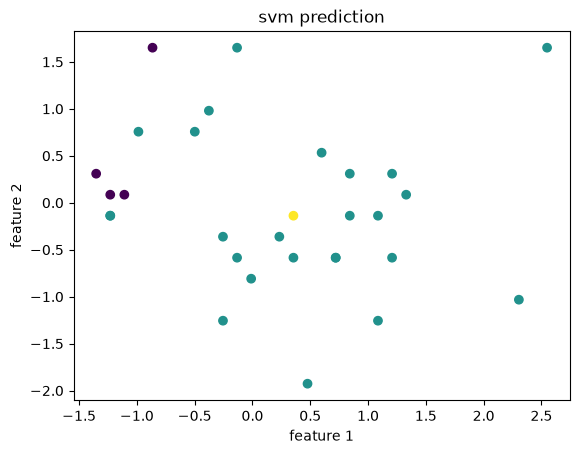

In [44]:
plt.scatter(
    x_test[:, 0],
    x_test[:, 1],
    c = f_prediction
)

plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('svm prediction' )
plt.show()